In [4]:
from ctypes import *
import numpy as np
import matplotlib.pyplot as plt

class mat(Structure):
    _fields_ = [('m', (c_double*3)*3)]

def f2(x,y,z,sepX,w):
    e1 = read_off(x,y,z,sepX,0,w)
    e2 = read_off(x,y,z,-sepX,0,w)

    return e1+e2

def read_off(x,y,z,sepX,sepY,w):
    mat_c = f(x,y,z,sepX,sepY,w)

    matrix = [[mat_c.m[0][0], mat_c.m[0][1], mat_c.m[0][2]],
              [mat_c.m[1][0], mat_c.m[1][1], mat_c.m[1][2]],
              [mat_c.m[2][0], mat_c.m[2][1], mat_c.m[2][2]]]
    
    return np.array(matrix)

In [5]:
f = CDLL("./cppScripts/test_func").test_func
f.argtypes = [c_double, c_double, c_double, c_double, c_double, c_double]
f.restype = mat
print(f2(0, 0, 0, 1,0))

[[ 72.   0.   0.]
 [  0. -42.   0.]
 [  0.   0. -30.]]


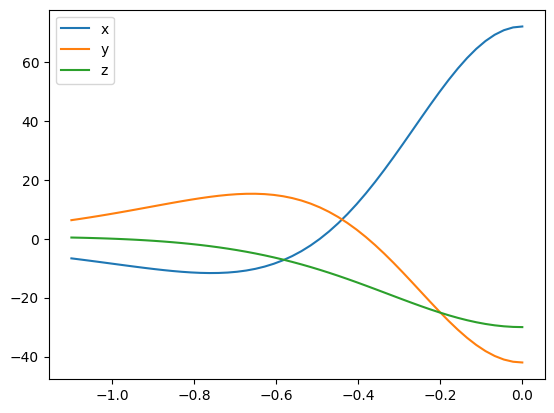

In [6]:
x = np.linspace(0,-1.1,50)
y0 = x.copy()
y1 = x.copy()
y2 = x.copy()
for i in range(len(x)):
    y0[i] = f2(0, x[i], 0, 1,0)[0][0]
    y1[i] = f2(0, x[i], 0, 1,0)[1][1]
    y2[i] = f2(0, x[i], 0, 1,0)[2][2]

plt.plot(x,y0,label='x')
plt.plot(x,y1,label='y')
plt.plot(x,y2,label='z')
plt.legend()

In [7]:
class vect(Structure):
    _fields_ = [('x', c_double*10000), 
                ('y', c_double*10000),
                ('z', c_double*10000), 
                ('m', c_double*10000),
                ('hArray', c_double*10000), 
                ('det', c_double*10000), 
                ('its', c_int)]

# load C++
rka_iter = CDLL("./cppScripts/rka_iter_custT_2Quad").rka_iter_double
rka_iter.argtypes = [c_double, c_double, c_double, c_double, c_double, c_double, c_int, c_int, c_double, c_double, c_double, c_double]
rka_iter.restype = vect

# RKA setup
num_its = 3 # Iterations per seed point
delta_0 = 10e-6 # Min deviation from next step
h0 = 10e-4 #Starting step size
safety = .98 # Scaling factor for step size change
ending_tolerance = .001 # How far from poles to step simulation
icity = -1

theta = 0
sep = 2

x = 0
y = .7
z = 0
vect_c = rka_iter(theta * np.pi, sep, 0, x, y, z, num_its, icity, ending_tolerance, delta_0, safety, h0)

its = vect_c.its
x = vect_c.x[0:its]
y = vect_c.y[0:its]
z = vect_c.z[0:its]

In [8]:
x,y,z

([], [], [])